# Notebook 04 — ROI Extraction, Hough Transform & Geometric Filtering

**Pipeline:** Adaptive Classical Vision Pipeline for Cut-Edge Detection  
**Step 4:** Edge map → Probabilistic Hough → geometric filtering → line merging

**Input:**
- Edge maps from `outputs/03_canny/`
- Rectified images from `outputs/02_rectified/`
- Calibration data from `outputs/02_rectified/calibration.json`

**Output:**
- Detected cut-edge lines saved to `outputs/04_hough/lines.json`
- Visualisations saved to `outputs/04_hough/`

**Expected output:** 4 cut edges per image (2 rubber band pairs × 2 cut edges each)

**Strategy:**
1. Run Probabilistic Hough Transform on the clean edge map from Notebook 03
2. Filter segments by orientation (near-vertical, since cut edges are vertical lines)
3. Filter by spatial position (exclude image borders, keep only inside table area)
4. Merge collinear nearby segments into representative cut-edge lines

## 1. Imports and configuration

In [36]:
!pip install opencv-python numpy matplotlib

In [37]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [38]:
# ── Paths ──────────────────────────────────────────────────────────────────
RECTIFIED_DIR = Path("outputs/02_rectified")
CANNY_DIR     = Path("outputs/03_canny")
CALIB_PATH    = RECTIFIED_DIR / "calibration.json"
OUTPUT_DIR    = Path("outputs/04_hough")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Probabilistic Hough parameters ────────────────────────────────────────
HOUGH_RHO        = 1
HOUGH_THETA      = np.pi / 180
HOUGH_THRESHOLD  = 50      # min votes to accept a line
HOUGH_MIN_LEN    = 80      # min segment length (px) — longer = fewer false positives
HOUGH_MAX_GAP    = 30      # max gap between collinear segments (px)

# ── Geometric filter parameters ────────────────────────────────────────────
# Cut edges are approximately vertical lines.
MAX_ANGLE_FROM_VERTICAL = 25   # degrees — stricter than before

# Spatial filter: how far inside the QR-defined table area segments must be.
# Positive = inward margin (excludes image borders and QR areas)
SPATIAL_MARGIN_X = 40    # px inward from QR x bounds
SPATIAL_MARGIN_Y = 20    # px inward from QR y bounds

# ── Merging parameters ─────────────────────────────────────────────────────
# Segments within this x-distance are considered part of the same cut edge.
# Must be large enough to merge fragments, small enough to keep separate edges apart.
MERGE_DIST_THR   = 80    # px

# Expected number of cut edges per image
EXPECTED_EDGES   = 4

# Load calibration
with open(CALIB_PATH) as f:
    calibration_data = json.load(f)

print(f"Calibrated images: {len(calibration_data)}")
print(f"Output dir       : {OUTPUT_DIR.resolve()}")

Calibrated images: 22
Output dir       : C:\Users\david\OneDrive\Documentos\UNI\VISION ARTIFICIAL\VA_RetoMichelin\models\David\outputs\04_hough


## 2. Probabilistic Hough Transform

In [39]:
def run_hough(edges: np.ndarray) -> np.ndarray:
    """
    Run Probabilistic Hough Transform on the edge map.
    Returns raw segments as array of shape (N, 1, 4) or None.
    """
    return cv2.HoughLinesP(
        edges,
        rho           = HOUGH_RHO,
        theta         = HOUGH_THETA,
        threshold     = HOUGH_THRESHOLD,
        minLineLength = HOUGH_MIN_LEN,
        maxLineGap    = HOUGH_MAX_GAP
    )

## 3. Geometric filtering

Keep only segments that are:
- **Near-vertical** (angle from vertical ≤ MAX_ANGLE_FROM_VERTICAL)
- **Inside the table area** with inward margin to exclude image borders and QR regions

In [40]:
def segment_angle_from_vertical(x1, y1, x2, y2) -> float:
    """Return angle in degrees between segment and vertical axis."""
    dx = abs(x2 - x1)
    dy = abs(y2 - y1)
    if dy == 0:
        return 90.0
    return float(np.degrees(np.arctan2(dx, dy)))


def filter_segments(segments, calib: dict, img_shape: tuple) -> list:
    """
    Filter Hough segments by orientation and spatial position.

    Uses an inward margin from the QR-defined table corners to exclude
    image border artifacts and QR code regions.
    """
    if segments is None:
        return []

    H, W = img_shape
    corners = np.array(calib['corners_px'])

    # Inward spatial bounds — excludes image borders and QR areas
    x_min = int(corners[:, 0].min()) + SPATIAL_MARGIN_X
    x_max = int(corners[:, 0].max()) - SPATIAL_MARGIN_X
    y_min = int(corners[:, 1].min()) + SPATIAL_MARGIN_Y
    y_max = int(corners[:, 1].max()) - SPATIAL_MARGIN_Y

    filtered = []
    for seg in segments:
        x1, y1, x2, y2 = seg[0]

        # Orientation: near-vertical
        if segment_angle_from_vertical(x1, y1, x2, y2) > MAX_ANGLE_FROM_VERTICAL:
            continue

        # Spatial: midpoint inside inward-margin table area
        mx, my = (x1 + x2) / 2, (y1 + y2) / 2
        if not (x_min <= mx <= x_max and y_min <= my <= y_max):
            continue

        filtered.append([int(x1), int(y1), int(x2), int(y2)])

    return filtered

## 4. Segment merging

Group segments that are close in x-position (same cut edge) and merge them
into a single representative vertical line spanning their full y range.

In [41]:
def merge_segments(filtered: list, dist_thr: int = MERGE_DIST_THR) -> list:
    return filtered 

## 5. Full pipeline per image

In [42]:
def process_image(image_name: str) -> dict | None:
    calib = calibration_data[image_name]
    edges = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    img   = cv2.imread(str(RECTIFIED_DIR / image_name))

    if edges is None or img is None:
        print(f"  [SKIP] {image_name}")
        return None

    H, W     = edges.shape
    segments = run_hough(edges)
    filtered = filter_segments(segments, calib, (H, W))
    merged   = merge_segments(filtered)

    return {
        'image_name'     : image_name,
        'n_raw_segments' : len(segments) if segments is not None else 0,
        'n_filtered'     : len(filtered),
        'n_merged'       : len(merged),
        'cut_edges_px'   : merged
    }

In [43]:
hough_results = {}

for image_name in calibration_data:
    result = process_image(image_name)
    if result is not None:
        hough_results[image_name] = result
        flag = "✓" if result['n_merged'] == EXPECTED_EDGES else "✗"
        print(f"  [{flag}] {image_name:30s}  "
              f"raw={result['n_raw_segments']:4d}  "
              f"filtered={result['n_filtered']:3d}  "
              f"merged={result['n_merged']:2d}")

correct = sum(1 for r in hough_results.values() if r['n_merged'] == EXPECTED_EDGES)
print(f"\nCorrect (n={EXPECTED_EDGES}): {correct} / {len(hough_results)} images")

with open(OUTPUT_DIR / "lines.json", "w") as f:
    json.dump(hough_results, f, indent=2)
print(f"Saved to {OUTPUT_DIR / 'lines.json'}")

  [✗] Multimedia_31.jpg               raw= 152  filtered= 41  merged=41
  [✗] Multimedia_32.jpg               raw= 200  filtered= 28  merged=28
  [✗] Multimedia_33.jpg               raw= 139  filtered= 29  merged=29
  [✗] Multimedia_34.jpg               raw= 131  filtered= 25  merged=25
  [✗] Multimedia_35.jpg               raw=  25  filtered=  0  merged= 0
  [✗] Multimedia_36.jpg               raw=  53  filtered=  0  merged= 0
  [✗] Multimedia_37.jpg               raw=  81  filtered=  0  merged= 0
  [✗] Multimedia_38.jpg               raw=  60  filtered=  0  merged= 0
  [✗] Multimedia_39.jpg               raw= 175  filtered= 25  merged=25
  [✗] Multimedia_40.jpg               raw= 154  filtered= 95  merged=95
  [✗] Multimedia_41.jpg               raw= 216  filtered= 25  merged=25
  [✗] Multimedia_42.jpg               raw= 182  filtered= 30  merged=30
  [✗] Multimedia_43.jpg               raw= 102  filtered=  0  merged= 0
  [✗] Multimedia_44.jpg               raw=  68  filtered=  0  me

## 6. Visual inspection

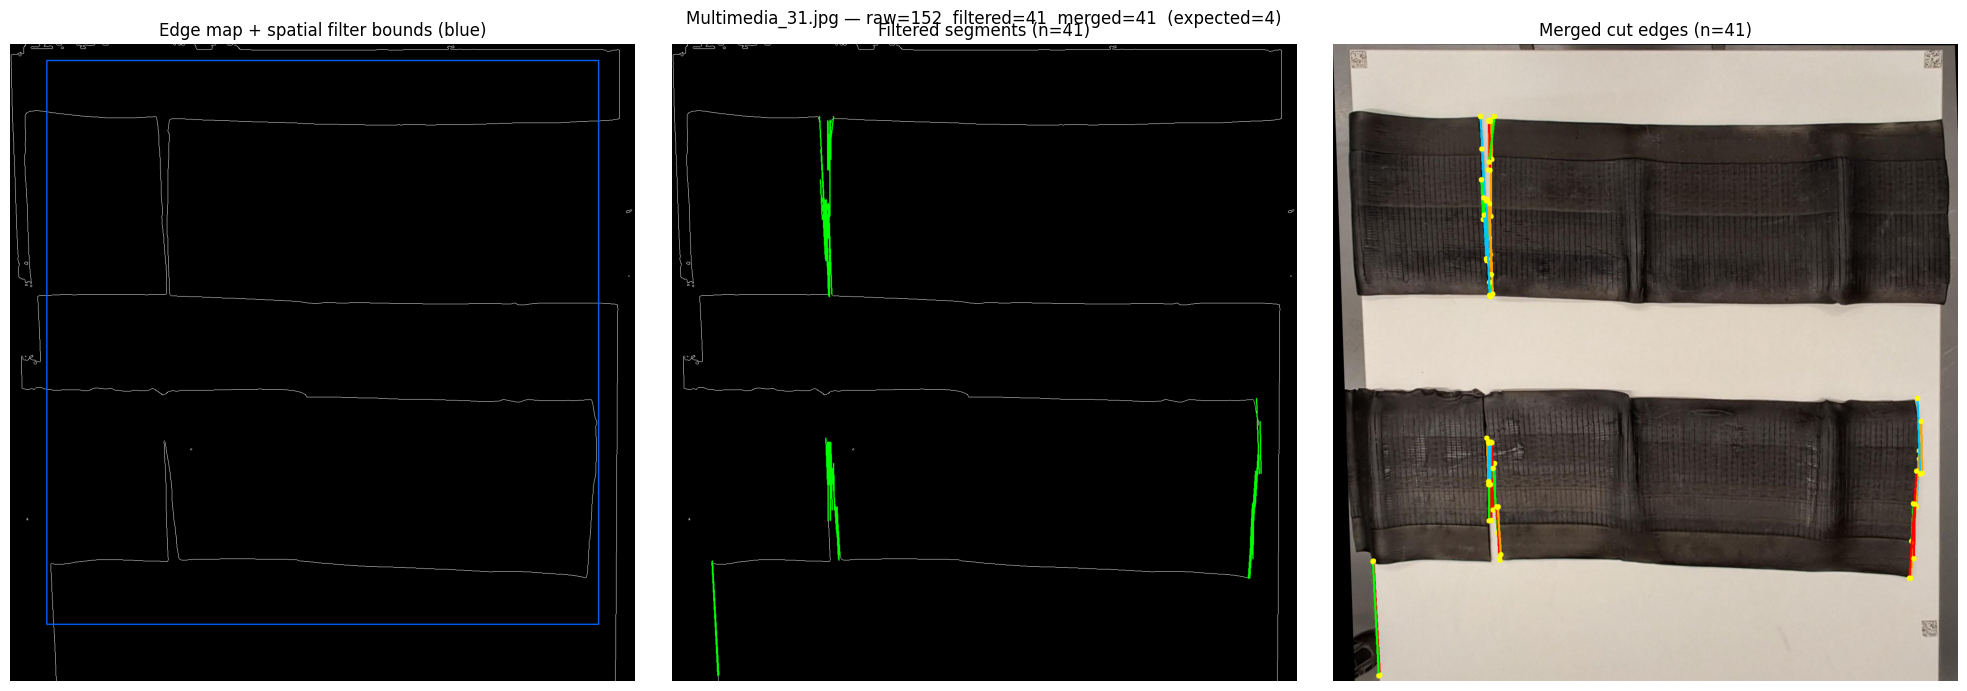

In [44]:
def visualize_result(image_name: str):
    result   = hough_results[image_name]
    calib    = calibration_data[image_name]
    img      = cv2.imread(str(RECTIFIED_DIR / image_name))
    edges    = cv2.imread(str(CANNY_DIR / image_name), cv2.IMREAD_GRAYSCALE)
    img_rgb  = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    H, W     = edges.shape

    segments = run_hough(edges)
    filtered = filter_segments(segments, calib, (H, W))
    merged   = result['cut_edges_px']

    # Draw spatial filter bounds on edge map
    corners = np.array(calib['corners_px'])
    x_min = int(corners[:, 0].min()) + SPATIAL_MARGIN_X
    x_max = int(corners[:, 0].max()) - SPATIAL_MARGIN_X
    y_min = int(corners[:, 1].min()) + SPATIAL_MARGIN_Y
    y_max = int(corners[:, 1].max()) - SPATIAL_MARGIN_Y

    fig, axes = plt.subplots(1, 3, figsize=(20, 7))
    fig.suptitle(f"{image_name} — raw={result['n_raw_segments']}  "
                 f"filtered={result['n_filtered']}  "
                 f"merged={result['n_merged']}  "
                 f"(expected={EXPECTED_EDGES})", fontsize=12)

    # Edge map with spatial bounds
    edge_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    cv2.rectangle(edge_vis, (x_min, y_min), (x_max, y_max), (0, 100, 255), 2)
    axes[0].imshow(edge_vis)
    axes[0].set_title('Edge map + spatial filter bounds (blue)')
    axes[0].axis('off')

    # Filtered segments
    filt_vis = cv2.cvtColor(edges, cv2.COLOR_GRAY2RGB)
    for x1, y1, x2, y2 in filtered:
        cv2.line(filt_vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
    axes[1].imshow(filt_vis)
    axes[1].set_title(f'Filtered segments (n={len(filtered)})')
    axes[1].axis('off')

    # Merged cut edges on original image
    overlay = img_rgb.copy()
    colors  = [(255,0,0), (0,200,255), (255,165,0), (0,255,0)]
    for i, (x1, y1, x2, y2) in enumerate(merged):
        color = colors[i % len(colors)]
        cv2.line(overlay, (x1, y1), (x2, y2), color, 3)
        cv2.circle(overlay, (x1, y1), 6, (255,255,0), -1)
        cv2.circle(overlay, (x2, y2), 6, (255,255,0), -1)
    axes[2].imshow(overlay)
    axes[2].set_title(f'Merged cut edges (n={len(merged)})')
    axes[2].axis('off')

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f'check_{image_name}', dpi=120)
    plt.show()


visualize_result(next(iter(hough_results)))

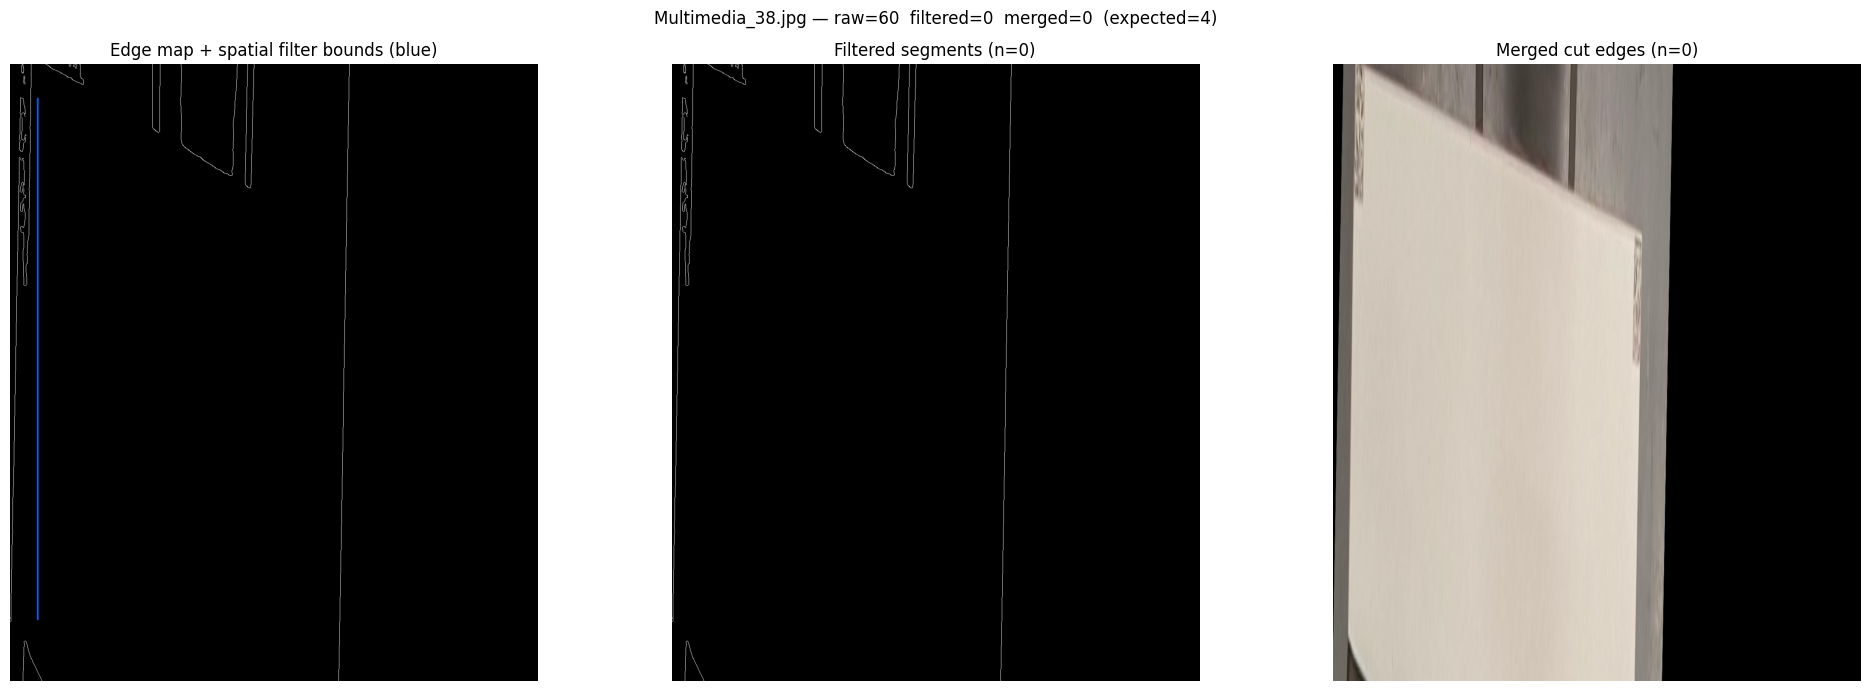

In [ ]:
# Visualize a specific image
#visualize_result("Multimedia_38.jpg")

## 7. Summary of detections across all images

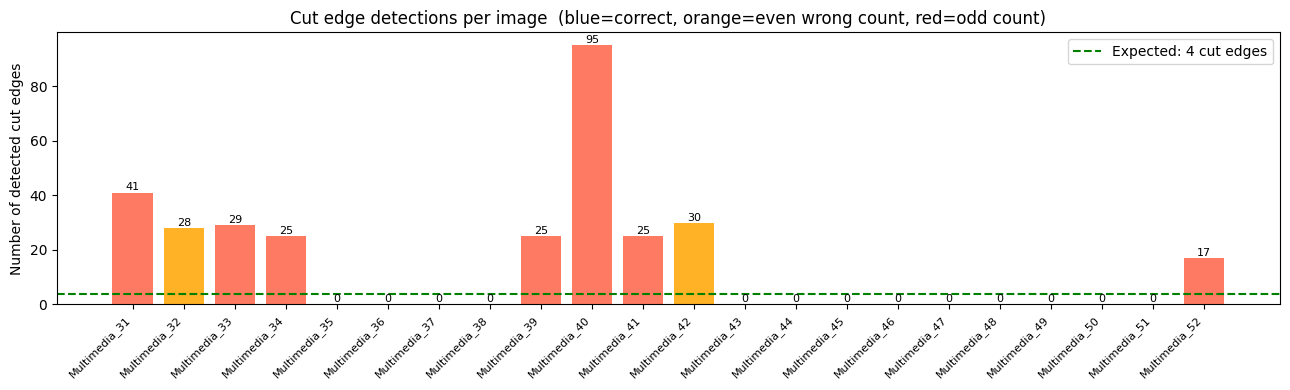

Correct (n=4)    : 0 / 22
Even wrong count : 15 / 22
Odd count (bad)  : 7 / 22


In [46]:
names   = list(hough_results.keys())
n_edges = [hough_results[n]['n_merged'] for n in names]

fig, ax = plt.subplots(figsize=(13, 4))
bar_colors = ['steelblue' if n == EXPECTED_EDGES else
              'tomato'    if n % 2 != 0          else
              'orange'    for n in n_edges]
bars = ax.bar(range(len(names)), n_edges, color=bar_colors, alpha=0.85)
for i, n in enumerate(n_edges):
    ax.text(i, n + 0.05, str(n), ha='center', va='bottom', fontsize=8)

ax.axhline(EXPECTED_EDGES, color='green', linestyle='--',
           label=f'Expected: {EXPECTED_EDGES} cut edges')
ax.set_xticks(range(len(names)))
ax.set_xticklabels([n.replace('.jpg', '') for n in names],
                   rotation=45, ha='right', fontsize=8)
ax.set_ylabel('Number of detected cut edges')
ax.set_title('Cut edge detections per image  '
             '(blue=correct, orange=even wrong count, red=odd count)')
ax.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'detection_summary.png', dpi=150)
plt.show()

correct = sum(1 for n in n_edges if n == EXPECTED_EDGES)
even    = sum(1 for n in n_edges if n != EXPECTED_EDGES and n % 2 == 0)
odd     = sum(1 for n in n_edges if n % 2 != 0)
print(f"Correct (n={EXPECTED_EDGES})    : {correct} / {len(names)}")
print(f"Even wrong count : {even} / {len(names)}")
print(f"Odd count (bad)  : {odd} / {len(names)}")

## 8. Summary

| Step | Operation | Parameters |
|------|-----------|------------|
| 4a | Probabilistic Hough | threshold=50, minLen=80px, maxGap=30px |
| 4b | Orientation filter | max angle from vertical = 25° |
| 4c | Spatial filter | inward margin x=40px, y=20px from QR bounds |
| 4d | Segment merging | x-distance threshold = 80px |

**Output folder:** `outputs/04_hough/`  
**Lines file:** `outputs/04_hough/lines.json`  
**Next notebook:** `05_metric.ipynb` — Metric estimation and evaluation